In [182]:
import numpy as np
import pandas as pd

rng = np.random.default_rng(42)
n = 500

timestamps = pd.date_range(
    "2025-10-01 08:00",
    periods=n,
    freq="1min"
)

cpu = rng.normal(35, 5, n)
error_rate = rng.exponential(0.002, n)
latency_p99 = rng.normal(150, 20, n)

# Inject anomalies at indices 200–215
cpu[200:216] = rng.normal(85, 5, 16)
error_rate[200:216] = rng.uniform(0.05, 0.15, 16)
latency_p99[200:216] = rng.normal(3500, 200, 16)

df = pd.DataFrame({
    "timestamp": timestamps,
    "cpu_pct": np.clip(cpu, 0, 100),
    "error_rate": np.clip(error_rate, 0, 1),
    "latency_p99_ms": np.clip(latency_p99, 0, None)
})

df.to_csv("metrics_sample.csv", index=False)

print("Dataset created successfully!")
print("Rows:", len(df))
df.head()

Dataset created successfully!
Rows: 500


,timestamp,cpu_pct,error_rate,latency_p99_ms
0,2025-10-01 08:00:00,36.523585,0.001369,129.579097
1,2025-10-01 08:01:00,29.800079,0.000826,151.043466
2,2025-10-01 08:02:00,38.752256,0.004541,144.522990
3,2025-10-01 08:03:00,39.702824,0.001072,143.263361
4,2025-10-01 08:04:00,25.244824,0.001947,162.394039


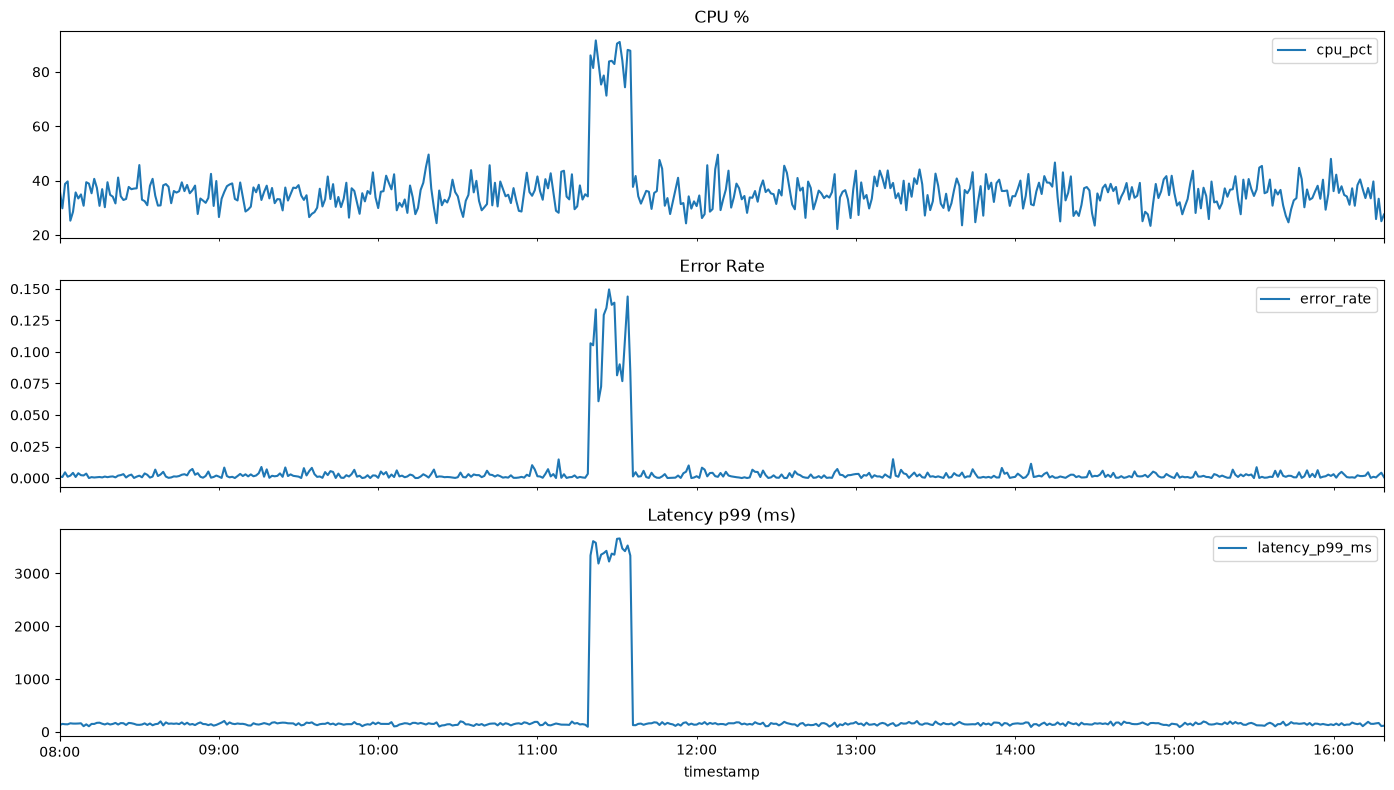

In [183]:
import matplotlib.pyplot as plt

fig, axes = plt.subplots(3, 1, figsize=(14, 8), sharex=True)

df.set_index("timestamp")[["cpu_pct"]].plot(
    ax=axes[0],
    title="CPU %"
)

df.set_index("timestamp")[["error_rate"]].plot(
    ax=axes[1],
    title="Error Rate"
)

df.set_index("timestamp")[["latency_p99_ms"]].plot(
    ax=axes[2],
    title="Latency p99 (ms)"
)

plt.tight_layout()
plt.savefig("metrics_overview.png", dpi=150)
plt.show()

In [184]:
from sklearn.ensemble import IsolationForest
from sklearn.preprocessing import StandardScaler

# Select the three metric features
features = df[["cpu_pct", "error_rate", "latency_p99_ms"]]

# Standardize the data
scaler = StandardScaler()
X = scaler.fit_transform(features)

# Train Isolation Forest
model = IsolationForest(
    n_estimators=200,
    contamination=0.04,
    random_state=42
)

model.fit(X)

# Calculate anomaly score and prediction
df["anomaly_score"] = model.decision_function(X)
df["is_anomaly"] = model.predict(X) == -1

# Display results
print(f"Anomalies detected: {df['is_anomaly'].sum()} of {len(df)} points")

df[df["is_anomaly"]][
    ["timestamp", "cpu_pct", "error_rate", "latency_p99_ms", "anomaly_score"]
]

Anomalies detected: 20 of 500 points


,timestamp,cpu_pct,error_rate,latency_p99_ms,anomaly_score
188,2025-10-01 11:08:00,28.159204,0.014775,147.952066,-0.039864
200,2025-10-01 11:20:00,86.051456,0.106817,3339.351982,-0.136243
201,2025-10-01 11:21:00,81.425617,0.105216,3610.238346,-0.158363
202,2025-10-01 11:22:00,91.560126,0.133661,3579.101821,-0.191103
203,2025-10-01 11:23:00,83.424128,0.060866,3186.588350,-0.169547
204,2025-10-01 11:24:00,75.327346,0.072518,3355.131496,-0.162411
205,2025-10-01 11:25:00,78.659930,0.129300,3383.655730,-0.141649
206,2025-10-01 11:26:00,71.251620,0.134784,3426.906081,-0.169547
207,2025-10-01 11:27:00,83.829372,0.149482,3224.817282,-0.163426
208,2025-10-01 11:28:00,84.058079,0.137291,3374.325778,-0.130391


In [185]:
from sklearn.metrics import classification_report, confusion_matrix

# Ground truth:
# indices 200–215 are the true injected anomalies
ground_truth = [1 if 200 <= i <= 215 else 0 for i in range(len(df))]

# Model predictions
predictions = df["is_anomaly"].astype(int).tolist()

# Classification report
print("Classification Report:")
print(
    classification_report(
        ground_truth,
        predictions,
        target_names=["Normal", "Anomaly"]
    )
)

# Confusion matrix
print("Confusion Matrix:")
print(confusion_matrix(ground_truth, predictions))

Classification Report:
              precision    recall  f1-score   support

      Normal       1.00      0.99      1.00       484
     Anomaly       0.80      1.00      0.89        16

    accuracy                           0.99       500
   macro avg       0.90      1.00      0.94       500
weighted avg       0.99      0.99      0.99       500

Confusion Matrix:
[[480   4]
 [  0  16]]


In [186]:
from sklearn.metrics import precision_score, recall_score, f1_score

contamination_values = [0.01, 0.04, 0.10]

results = []

for contamination in contamination_values:
    
    test_model = IsolationForest(
        n_estimators=200,
        contamination=contamination,
        random_state=42
    )
    
    test_model.fit(X)
    
    test_predictions = (test_model.predict(X) == -1).astype(int)
    
    precision = precision_score(ground_truth, test_predictions)
    recall = recall_score(ground_truth, test_predictions)
    f1 = f1_score(ground_truth, test_predictions)
    
    results.append({
        "Contamination": contamination,
        "Detected Anomalies": int(test_predictions.sum()),
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    })

results_df = pd.DataFrame(results)

results_df

,Contamination,Detected Anomalies,Precision,Recall,F1 Score
0,0.01,4,1.00,0.25,0.400000
1,0.04,20,0.80,1.00,0.888889
2,0.10,50,0.32,1.00,0.484848


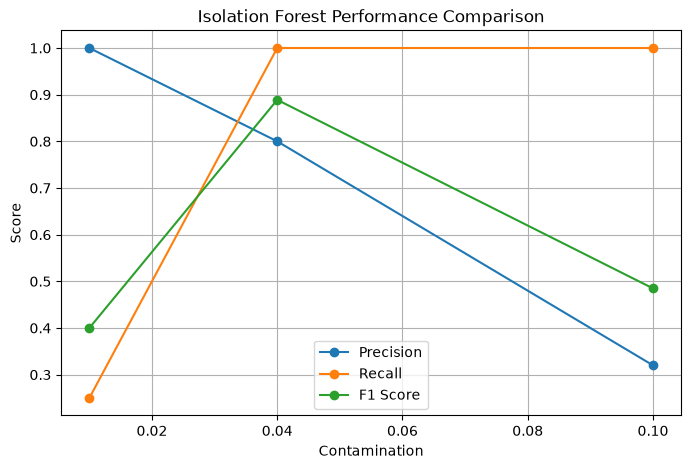

In [187]:
plt.figure(figsize=(8, 5))

plt.plot(
    results_df["Contamination"],
    results_df["Precision"],
    marker="o",
    label="Precision"
)

plt.plot(
    results_df["Contamination"],
    results_df["Recall"],
    marker="o",
    label="Recall"
)

plt.plot(
    results_df["Contamination"],
    results_df["F1 Score"],
    marker="o",
    label="F1 Score"
)

plt.xlabel("Contamination")
plt.ylabel("Score")
plt.title("Isolation Forest Performance Comparison")
plt.legend()
plt.grid(True)

plt.savefig(
    "contamination_comparison.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

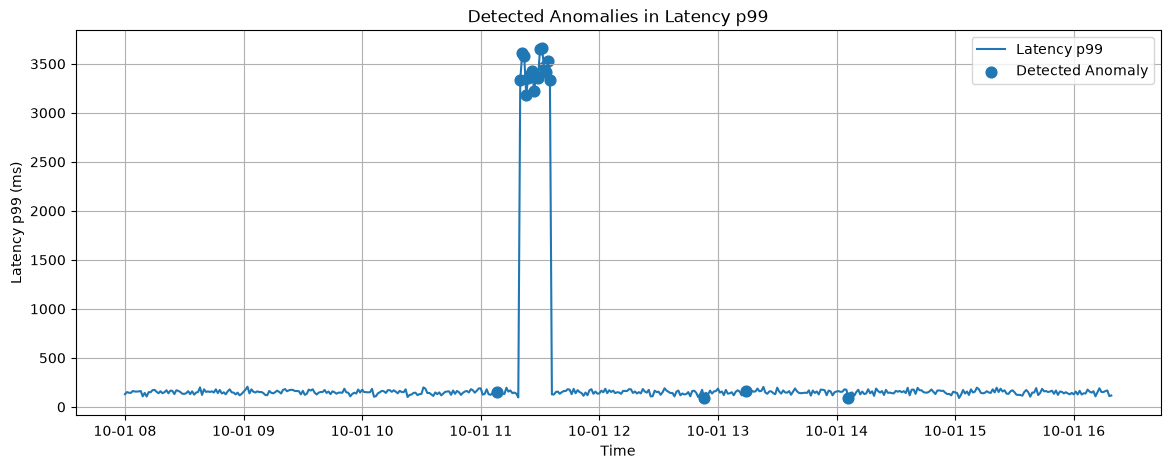

In [188]:
# Plot detected anomalies on latency

plt.figure(figsize=(14, 5))

# Original latency line
plt.plot(
    df["timestamp"],
    df["latency_p99_ms"],
    label="Latency p99"
)

# Detected anomaly points
anomalies = df[df["is_anomaly"]]

plt.scatter(
    anomalies["timestamp"],
    anomalies["latency_p99_ms"],
    marker="o",
    s=60,
    label="Detected Anomaly"
)

plt.xlabel("Time")
plt.ylabel("Latency p99 (ms)")
plt.title("Detected Anomalies in Latency p99")

plt.legend()
plt.grid(True)

plt.savefig(
    "detected_anomalies.png",
    dpi=150,
    bbox_inches="tight"
)

plt.show()

In [189]:
from src.alert_grouper import create_alerts, group_alerts

# Create alert records from detected anomalies
alerts_df = create_alerts(df)

# Group alerts occurring within 5 minutes
grouped_alerts = group_alerts(alerts_df, window_minutes=5)

print("Total alerts:", len(grouped_alerts))
print(
    "Total incidents:",
    grouped_alerts["incident_id"].nunique()
)

grouped_alerts

Total alerts: 20
Total incidents: 5


,timestamp,cpu_pct,error_rate,latency_p99_ms,incident_id
0,2025-10-01 11:08:00,28.159204,0.014775,147.952066,1
1,2025-10-01 11:20:00,86.051456,0.106817,3339.351982,2
2,2025-10-01 11:21:00,81.425617,0.105216,3610.238346,2
3,2025-10-01 11:22:00,91.560126,0.133661,3579.101821,2
4,2025-10-01 11:23:00,83.424128,0.060866,3186.588350,2
5,2025-10-01 11:24:00,75.327346,0.072518,3355.131496,2
6,2025-10-01 11:25:00,78.659930,0.129300,3383.655730,2
7,2025-10-01 11:26:00,71.251620,0.134784,3426.906081,2
8,2025-10-01 11:27:00,83.829372,0.149482,3224.817282,2
9,2025-10-01 11:28:00,84.058079,0.137291,3374.325778,2


In [190]:
incident_summary = (
    grouped_alerts
    .groupby("incident_id")
    .agg(
        start_time=("timestamp", "min"),
        end_time=("timestamp", "max"),
        alert_count=("timestamp", "count"),
        max_cpu_pct=("cpu_pct", "max"),
        max_error_rate=("error_rate", "max"),
        max_latency_p99_ms=("latency_p99_ms", "max")
    )
    .reset_index()
)

incident_summary

,incident_id,start_time,end_time,alert_count,max_cpu_pct,max_error_rate,max_latency_p99_ms
0,1,2025-10-01 11:08:00,2025-10-01 11:08:00,1,28.159204,0.014775,147.952066
1,2,2025-10-01 11:20:00,2025-10-01 11:35:00,16,91.560126,0.149482,3661.824262
2,3,2025-10-01 12:53:00,2025-10-01 12:53:00,1,22.166708,0.007172,94.440114
3,4,2025-10-01 13:14:00,2025-10-01 13:14:00,1,39.139941,0.014941,164.840578
4,5,2025-10-01 14:06:00,2025-10-01 14:06:00,1,31.282059,0.011350,92.658901


In [191]:
from datetime import datetime, timedelta
import random

random.seed(42)

start_time = datetime(2025, 10, 1, 8, 0)

log_lines = []

for i in range(250):
    current_time = start_time + timedelta(minutes=i)

    # Simulated incident around 11:20–11:35
    if 200 <= i <= 215:
        messages = [
            "ERROR database connection pool exhausted",
            "ERROR request timeout while accessing database",
            "WARN API latency exceeded threshold",
            "ERROR failed to acquire database connection",
            "WARN CPU utilization above normal range"
        ]
        level_message = random.choice(messages)

    else:
        messages = [
            "INFO request completed successfully",
            "INFO health check passed",
            "INFO database query completed",
            "INFO API response sent",
            "INFO background job completed"
        ]
        level_message = random.choice(messages)

    line = (
        f"{current_time.strftime('%Y-%m-%d %H:%M:%S')} "
        f"{level_message}"
    )

    log_lines.append(line)

with open("data/logs_sample.txt", "w", encoding="utf-8") as f:
    f.write("\n".join(log_lines))

print(f"Created {len(log_lines)} log lines.")
print("\nSample incident logs:")
print("\n".join(log_lines[200:216]))

Created 250 log lines.

Sample incident logs:
2025-10-01 11:20:00 ERROR database connection pool exhausted
2025-10-01 11:21:00 ERROR database connection pool exhausted
2025-10-01 11:22:00 ERROR request timeout while accessing database
2025-10-01 11:23:00 ERROR database connection pool exhausted
2025-10-01 11:24:00 ERROR database connection pool exhausted
2025-10-01 11:25:00 WARN API latency exceeded threshold
2025-10-01 11:26:00 ERROR database connection pool exhausted
2025-10-01 11:27:00 WARN CPU utilization above normal range
2025-10-01 11:28:00 ERROR request timeout while accessing database
2025-10-01 11:29:00 WARN API latency exceeded threshold
2025-10-01 11:30:00 ERROR failed to acquire database connection
2025-10-01 11:31:00 ERROR request timeout while accessing database
2025-10-01 11:32:00 WARN CPU utilization above normal range
2025-10-01 11:33:00 ERROR request timeout while accessing database
2025-10-01 11:34:00 WARN CPU utilization above normal range
2025-10-01 11:35:00 WARN 

In [192]:
from src.rca_agent import (
    get_metric_context,
    get_log_context,
    generate_rca
)

incident_start = "2025-10-01 11:20:00"
incident_end = "2025-10-01 11:35:00"

metric_context = get_metric_context(
    "metrics_sample.csv",
    incident_start,
    incident_end
)

log_context = get_log_context(
    "data/logs_sample.txt",
    incident_start,
    incident_end
)

print("METRICS TOOL OUTPUT:")
print(metric_context)

print("\nLOG TOOL OUTPUT:")
print(f"Retrieved {len(log_context)} log lines")

print("\nFirst 5 logs:")
for line in log_context[:5]:
    print(line)

METRICS TOOL OUTPUT:
{'max_cpu_pct': np.float64(91.56), 'max_error_rate': np.float64(0.1495), 'max_latency_p99_ms': np.float64(3661.82)}

LOG TOOL OUTPUT:
Retrieved 16 log lines

First 5 logs:
2025-10-01 11:20:00 ERROR database connection pool exhausted
2025-10-01 11:21:00 ERROR database connection pool exhausted
2025-10-01 11:22:00 ERROR request timeout while accessing database
2025-10-01 11:23:00 ERROR database connection pool exhausted
2025-10-01 11:24:00 ERROR database connection pool exhausted


In [193]:
rca_result = generate_rca(
    "metrics_sample.csv",
    "data/logs_sample.txt",
    incident_start,
    incident_end
)

print("ROOT CAUSE:")
print(rca_result["root_cause"])

print("\nEVIDENCE:")
for item in rca_result["evidence"]:
    print("-", item)

print("\nRECOMMENDATIONS:")
for item in rca_result["recommendations"]:
    print("-", item)

ROOT CAUSE:
Database connection pool exhaustion likely caused application requests to wait for database connections.

EVIDENCE:
- Peak CPU: 91.56%
- Peak error rate: 0.1495
- Peak p99 latency: 3661.82 ms
- Relevant log lines: 16
- Database-related log events: 10
- Timeout events: 4

RECOMMENDATIONS:
- Increase or dynamically scale the database connection pool.
- Add monitoring for database connection pool utilization.
- Configure timeout and retry limits.
- Add alerts before p99 latency reaches a critical level.


In [194]:
from src.telemetry import (
    setup_tracer,
    run_instrumented_agent
)

tracer = setup_tracer()

instrumented_result = run_instrumented_agent(
    tracer,
    generate_rca,
    "metrics_sample.csv",
    "data/logs_sample.txt",
    incident_start,
    incident_end
)

print("Instrumented RCA run completed.")
print("\nRoot Cause:")
print(instrumented_result["root_cause"])

Overriding of current TracerProvider is not allowed


Instrumented RCA run completed.

Root Cause:
Database connection pool exhaustion likely caused application requests to wait for database connections.


In [195]:
import time
import pandas as pd

# Five different log window sizes
window_sizes = [500, 1000, 2000, 4000, 8000]

telemetry_results = []

with open("data/logs_sample.txt", "r", encoding="utf-8") as f:
    full_logs = f.read()

for size in window_sizes:
    log_window = full_logs[:size]

    # Simple token estimate:
    # about 4 characters per token
    input_tokens = max(1, len(log_window) // 4)

    # Simulated fixed output size
    output_tokens = 120

    start = time.perf_counter()

    # Simulate agent processing work
    _ = log_window.lower().count("error")
    _ = log_window.lower().count("warn")
    _ = log_window.lower().count("database")

    latency_ms = (time.perf_counter() - start) * 1000

    # Simulated agent = zero real API cost
    estimated_cost = 0.0

    telemetry_results.append({
        "Log Window Size (chars)": len(log_window),
        "Input Tokens": input_tokens,
        "Output Tokens": output_tokens,
        "Latency (ms)": round(latency_ms, 4),
        "Estimated Cost ($)": estimated_cost
    })

telemetry_df = pd.DataFrame(telemetry_results)

telemetry_df

,Log Window Size (chars),Input Tokens,Output Tokens,Latency (ms),Estimated Cost ($)
0,500,125,120,0.0051,0.0
1,1000,250,120,0.0036,0.0
2,2000,500,120,0.0051,0.0
3,4000,1000,120,0.0104,0.0
4,8000,2000,120,0.0168,0.0


### Agent Telemetry Experiment

Five log windows of different sizes were tested.

The estimated input token count increased approximately linearly with log window size because the experiment used a simple estimate of about four characters per token.

The simulated RCA agent did not call a paid LLM API, so the actual API cost was $0.00. In a production system, cost would increase as the number and size of log windows increase.

The measured latency in this simulation is very small because no external LLM API call was made.

In [ ]:
from src.rca_agent import generate_rca

test_rca = generate_rca(
    "metrics_sample.csv",
    "data/logs_sample.txt",
    "2025-10-01 11:20:00",
    "2025-10-01 11:35:00"
)

print("Agent Mode:", test_rca["mode"])
print("Model:", test_rca["model"])

test_rca

KeyError: 'mode'

{
    "name": "gen_ai.rca_agent",
    "context": {
        "trace_id": "0xd605e7708a63f881ffd0f9d5a6f2f7b8",
        "span_id": "0xf810238303c72ba8",
        "trace_state": "[]"
    },
    "kind": "SpanKind.INTERNAL",
    "parent_id": null,
    "start_time": "2026-08-08T06:11:36.864620Z",
    "end_time": "2026-08-08T06:11:36.944758Z",
    "status": {
        "status_code": "UNSET"
    },
    "attributes": {
        "gen_ai.system": "simulated",
        "gen_ai.request.model": "simulated-rca-agent",
        "gen_ai.usage.input_tokens": 420,
        "gen_ai.usage.output_tokens": 120,
        "agent.latency_ms": 79.31,
        "agent.estimated_cost_usd": 0.0
    },
    "events": [],
    "links": [],
    "resource": {
        "attributes": {
            "telemetry.sdk.language": "python",
            "telemetry.sdk.name": "opentelemetry",
            "telemetry.sdk.version": "1.44.0",
            "service.instance.id": "84f24bca-e181-4efc-8a13-1ca6f19aaeaf",
            "service.name": "un

In [ ]:
import importlib
import src.rca_agent as rca_agent

# Reload the updated Python file
importlib.reload(rca_agent)

test_rca = rca_agent.generate_rca(
    "metrics_sample.csv",
    "data/logs_sample.txt",
    "2025-10-01 11:20:00",
    "2025-10-01 11:35:00"
)

print("Agent Mode:", test_rca["mode"])
print("Model:", test_rca["model"])

test_rca

KeyError: 'mode'

In [197]:
import importlib
import src.rca_agent as rca_agent

importlib.reload(rca_agent)

test_rca = rca_agent.generate_rca(
    "metrics_sample.csv",
    "data/logs_sample.txt",
    "2025-10-01 11:20:00",
    "2025-10-01 11:35:00"
)

print("Agent Mode:", test_rca["mode"])
print("Model:", test_rca["model"])

test_rca

Agent Mode: simulated
Model: simulated-rca-agent


{'mode': 'simulated',
 'model': 'simulated-rca-agent',
 'incident_window': '2025-10-01 11:20:00 to 2025-10-01 11:35:00',
 'root_cause': 'Database connection pool exhaustion likely caused application requests to wait for database connections.',
 'evidence': ['Peak CPU: 91.56%',
  'Peak error rate: 0.1495',
  'Peak p99 latency: 3661.82 ms',
  'Relevant log lines: 16',
  'Database-related log events: 10',
  'Timeout events: 4'],
 'recommendations': ['Increase or dynamically scale the database connection pool.',
  'Add monitoring for database connection pool utilization.',
  'Configure timeout and retry limits.',
  'Add alerts before p99 latency reaches a critical level.']}

In [198]:
# Monthly LLM cost estimate using Claude Sonnet 5 standard pricing

input_price_per_million = 3.00
output_price_per_million = 15.00

calls_per_minute = 10
minutes_per_hour = 60
hours_per_day = 24
days_per_month = 30

calls_per_month = (
    calls_per_minute
    * minutes_per_hour
    * hours_per_day
    * days_per_month
)

# Example workload from the telemetry experiment
input_tokens_per_call = 1000
output_tokens_per_call = 120

input_cost_per_call = (
    input_tokens_per_call / 1_000_000
) * input_price_per_million

output_cost_per_call = (
    output_tokens_per_call / 1_000_000
) * output_price_per_million

cost_per_call = (
    input_cost_per_call
    + output_cost_per_call
)

monthly_cost = cost_per_call * calls_per_month

print(f"Calls per month: {calls_per_month:,}")
print(f"Input cost per call: ${input_cost_per_call:.6f}")
print(f"Output cost per call: ${output_cost_per_call:.6f}")
print(f"Total cost per call: ${cost_per_call:.6f}")
print(f"Estimated monthly cost: ${monthly_cost:,.2f}")

Calls per month: 432,000
Input cost per call: $0.003000
Output cost per call: $0.001800
Total cost per call: $0.004800
Estimated monthly cost: $2,073.60


### Cost Analysis

Using Claude Sonnet 5 standard pricing of $3 per million input tokens and $15 per million output tokens, I estimated the cost of continuous production use.

At 10 log windows per minute:

10 × 60 × 24 × 30 = 432,000 calls per month.

For an example request containing 1,000 input tokens and 120 output tokens, the estimated cost is approximately $0.0048 per call.

At 432,000 calls per month, the estimated monthly LLM cost would be approximately $2,073.60.

This demonstrates that even a low per-request cost can accumulate significantly when an agent operates continuously.

### Production Guardrails and Dashboard

**Cost Guardrail**

I would enforce a maximum log-window size and maximum input-token limit for each RCA request. I would also apply request-rate limits and a monthly spending budget. If the system approaches its budget threshold, non-critical RCA requests should be sampled or temporarily stopped.

**Production Dashboard Metrics**

A production-grade dashboard for this agent should track:

1. Input tokens per request
2. Output tokens per request
3. Agent latency
4. Estimated LLM cost
5. Agent error and failure rate

Additional useful metrics would include anomaly volume, grouped incident count, tool-call failures, and RCA generation success rate.